# intact_images — reference arm

Frozen CNN features from the **unmodified** facial images, probed with a
linear classifier. This is the reference arm for the image stream:
`blurred_images` and `background_images` reuse everything here and change
only the transform passed into embedding extraction.

## 1. Imports, config, device check

In [1]:
import logging
import random
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)

from experiments.intact_images.config import Config
from experiments.intact_images.pipeline import (
    step_1_manifest,
    step_2_embeddings,
    step_3_probe,
    step_4_summary,
)

cfg = Config(seed=42)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"data_root:  {cfg.data_root}")
print(f"output_dir: {cfg.output_dir}")

torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER
data_root:  C:\Projects\Autism Screening\data\raw\images
output_dir: C:\Projects\Autism Screening\outputs\intact_images


## 2. Manifest

In [2]:
manifest = step_1_manifest(cfg)
print(f"total rows: {len(manifest)}")
manifest.groupby(["split", "class_label"]).size().unstack()

total rows: 2940


class_label,autistic,non_autistic
split,,
test,150,150
train,1193,1193
valid,127,127


## 3. Visual check: the shared transform

Six sampled images, before and after `intact_transform` (EXIF orientation,
RGB, letterbox pad to square, resize, ImageNet normalisation). Letterboxing
rather than a centre crop keeps the full frame -- including background --
which the `background_images` experiment later depends on.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

from src.data.transforms import IMAGENET_MEAN, IMAGENET_STD, intact_transform

transform = intact_transform(size=cfg.image_size)
sample = manifest.sample(6, random_state=cfg.seed).reset_index(drop=True)

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, row in sample.iterrows():
    original = Image.open(row["path"]).convert("RGB")
    transformed = transform(Image.open(row["path"]))
    denormalized = (transformed * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[0, i].imshow(original)
    axes[0, i].set_title(f"{row['class_label']}\n{row['filename']}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(denormalized)
    axes[1, i].axis("off")

fig.text(0.01, 0.72, "original", va="center", rotation=90, fontsize=11)
fig.text(0.01, 0.28, "transformed", va="center", rotation=90, fontsize=11)
fig.suptitle("intact_transform: before (top) vs after (bottom)")
fig.tight_layout(rect=[0.02, 0, 1, 1])
plt.show()

## 4. Frozen-backbone embeddings

Loads the cache under `outputs/intact_images/` if it exists and its
metadata matches this config; otherwise runs frozen ResNet-50
(`IMAGENET1K_V2`) on the GPU and writes the cache.

In [4]:
import time

cache_path = cfg.output_dir / "embeddings.npy"
had_cache_before = cache_path.exists()

t0 = time.perf_counter()
embeddings = step_2_embeddings(cfg, manifest)
elapsed = time.perf_counter() - t0

print(f"embeddings shape: {embeddings.shape}")
print(f"cache present before this call: {had_cache_before}")
print(f"wall-clock for this call: {elapsed:.2f}s")

2026-09-06 16:33:34,793 [INFO] experiments.intact_images.pipeline: step_2_embeddings: using cached embeddings, shape=(2940, 2048)


embeddings shape: (2940, 2048)
cache present before this call: True
wall-clock for this call: 0.11s


## 5. Cross-validated probe

L2-penalised logistic regression behind a `StandardScaler`, pooling all
three published splits and cross-validating over the pool -- 10 repeats x
5 folds = 50 folds total. Frozen features, no fine-tuning, no threshold
tuning.

In [5]:
fold_results = step_3_probe(cfg, embeddings, manifest)
fold_results

,repeat,fold,roc_auc,balanced_accuracy,sensitivity,specificity
0,0,0,0.824165,0.746599,0.751701,0.741497
1,0,1,0.837440,0.773810,0.758503,0.789116
2,0,2,0.852666,0.775510,0.792517,0.758503
3,0,3,0.855963,0.792517,0.795918,0.789116
4,0,4,0.836908,0.746599,0.741497,0.751701
5,1,0,0.851775,0.775510,0.792517,0.758503
6,1,1,0.842861,0.765306,0.789116,0.741497
7,1,2,0.841565,0.763605,0.744898,0.782313
8,1,3,0.819300,0.734694,0.697279,0.772109
9,1,4,0.848651,0.770408,0.778912,0.761905


## 6. Summary

In [6]:
summary = step_4_summary(fold_results)
summary

,metric,mean,sd
0,roc_auc,0.841934,0.014667
1,balanced_accuracy,0.764524,0.016211
2,sensitivity,0.761088,0.027242
3,specificity,0.767959,0.023638


## 7. AUC across folds

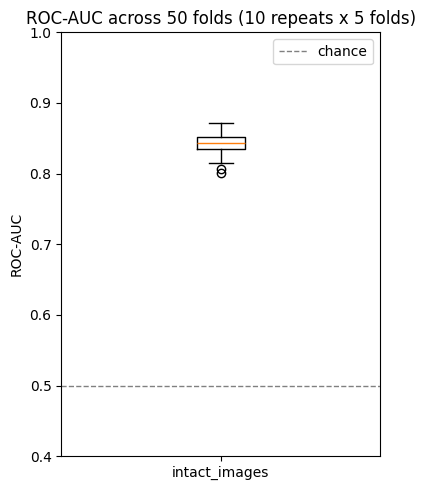

In [7]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(fold_results["roc_auc"], vert=True, tick_labels=["intact_images"])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.4, 1.0)
ax.set_title("ROC-AUC across 50 folds (10 repeats x 5 folds)")
ax.legend()
fig.tight_layout()
plt.show()

## 8. What this number means

The reference-arm probe on **intact, unmodified images** achieves the mean
ROC-AUC reported in the summary table above, using only frozen ResNet-50
features behind a linear classifier -- no fine-tuning, no threshold tuning.

**Known limitation, not fixed here.** The Phase 0 audit (`facial-images.ipynb`)
found 11 near-duplicate image pairs by perceptual hash, 5 of which cross the
published train/test/valid boundaries. This probe pools all three published
splits and cross-validates over the pool, so a duplicate can land on both
sides of a fold within a repeat, mildly inflating the result. Eleven pairs
out of 2,940 images is a small fraction, and grouping properly needs
perceptual-hash clustering that hasn't been built for this experiment yet --
`repeated_stratified_cv`'s `groups=` parameter is the seam where that fix
goes once it exists.

**Comparison to the metadata-only probe.** `facial-images.ipynb`'s
metadata-only audit -- dimensions, file size, JPEG quality, colour
statistics, EXIF, with no pixel content at all -- separated the two classes
at ROC-AUC 0.72-0.77. This experiment's own run landed at approximately
0.84 (see the summary table above for the exact figure): comfortably above
that range, meaning most of the intact-image score is *not* explained by
the metadata confound alone. That doesn't rule out a subtler pixel-level
confound (consistent framing, background, or processing correlated with
class) -- distinguishing genuine facial signal from that possibility is
exactly the job of the `blurred_images` and `background_images` experiments
that follow.